In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib


In [3]:
import seaborn as sns
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
df = pd.read_csv( r"C:\Users\mauri\OneDrive\ドキュメント\Regression_analysis_mobile_application\Corruption indicator Data of 180 Governments\wgidataset.csv" )

In [5]:
df.head(50)

,Unnamed: 0,code,countryname,year,vae,vas,van,var,val,vau,...,rln,rlr,rll,rlu,cce,ccs,ccn,ccr,ccl,ccu
0,0,ABW,Aruba,1996,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,ABW,Aruba,1998,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,ABW,Aruba,2000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,ABW,Aruba,2002,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,ABW,Aruba,2003,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,5,ABW,Aruba,2004,0.737521,0.338822,1.0,73.076920,56.250000,88.942310,...,1.0,80.769230,60.576923,91.826920,1.165965,0.393849,1.0,85.221670,71.428570,92.610840
6,6,ABW,Aruba,2005,1.153230,0.357602,1.0,85.576920,64.903850,100.000000,...,1.0,77.990430,57.894737,90.909090,1.269663,0.340958,1.0,88.292690,72.682930,93.170730
7,7,ABW,Aruba,2006,1.017273,0.491849,1.0,80.288460,53.846153,100.000000,...,1.0,72.727270,55.980860,90.430620,1.251313,0.418965,1.0,88.292690,72.195120,94.634150
8,8,ABW,Aruba,2007,0.972129,0.511656,1.0,78.365390,52.884617,100.000000,...,1.0,75.119610,57.894737,89.952156,1.261871,0.415193,1.0,88.349520,72.815540,93.689320
9,9,ABW,Aruba,2008,0.967198,0.511172,1.0,79.326920,51.442307,100.000000,...,1.0,76.442310,58.653847,89.903850,1.276775,0.401245,1.0,87.378640,73.300970,94.660194


In [6]:
nbr_rows, nbr_columns = df.shape
print("Number of rows:", nbr_rows)
print("Number of columns:", nbr_columns)

Number of rows: 4922
Number of columns: 40


In [18]:
df.columns

Index(['Unnamed: 0', 'code', 'countryname', 'year', 'vae', 'vas', 'van', 'var',
       'val', 'vau', 'pve', 'pvs', 'pvn', 'pvr', 'pvl', 'pvu', 'gee', 'ges',
       'gen', 'ger', 'gel', 'geu', 'rqe', 'rqs', 'rqn', 'rqr', 'rql', 'rqu',
       'rle', 'rls', 'rln', 'rlr', 'rll', 'rlu', 'cce', 'ccs', 'ccn', 'ccr',
       'ccl', 'ccu'],
      dtype='object')

In [7]:
df.tail()

,Unnamed: 0,code,countryname,year,vae,vas,van,var,val,vau,...,rln,rlr,rll,rlu,cce,ccs,ccn,ccr,ccl,ccu
4917,4917,ZWE,Zimbabwe,2017,-1.195904,0.119706,15.0,14.778325,10.837439,21.674877,...,15.0,7.211538,4.326923,10.576923,-1.281081,0.124858,15.0,9.615385,4.326923,12.500000
4918,4918,ZWE,Zimbabwe,2018,-1.140975,0.123371,15.0,16.908213,12.077294,21.739130,...,15.0,8.173077,5.288462,14.423077,-1.227581,0.125622,15.0,10.096154,6.250000,13.942307
4919,4919,ZWE,Zimbabwe,2019,-1.164705,0.118156,13.0,16.425121,12.077294,21.256039,...,14.0,7.211538,5.288462,13.942307,-1.273280,0.135450,14.0,10.096154,3.846154,13.942307
4920,4920,ZWE,Zimbabwe,2020,-1.113716,0.120647,12.0,17.874395,13.043478,23.188406,...,12.0,7.692308,4.807692,13.942307,-1.289440,0.142061,12.0,9.615385,3.846154,15.384615
4921,4921,ZWE,Zimbabwe,2021,-1.136934,0.121119,12.0,18.357489,12.560387,22.705315,...,12.0,8.653846,5.288462,15.865385,-1.257897,0.154067,11.0,8.653846,4.326923,16.346153


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4922 entries, 0 to 4921
Data columns (total 40 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   4922 non-null   int64  
 1   code         4922 non-null   object 
 2   countryname  4922 non-null   object 
 3   year         4922 non-null   int64  
 4   vae          4768 non-null   float64
 5   vas          4768 non-null   float64
 6   van          4768 non-null   float64
 7   var          4768 non-null   float64
 8   val          4768 non-null   float64
 9   vau          4768 non-null   float64
 10  pve          4753 non-null   float64
 11  pvs          4753 non-null   float64
 12  pvn          4753 non-null   float64
 13  pvr          4753 non-null   float64
 14  pvl          4753 non-null   float64
 15  pvu          4753 non-null   float64
 16  gee          4679 non-null   float64
 17  ges          4679 non-null   float64
 18  gen          4679 non-null   float64
 19  ger   

In [9]:
df.isnull().sum()

Unnamed: 0       0
code             0
countryname      0
year             0
vae            154
vas            154
van            154
var            154
val            154
vau            154
pve            169
pvs            169
pvn            169
pvr            169
pvl            169
pvu            169
gee            243
ges            243
gen            243
ger            243
gel            243
geu            243
rqe            241
rqs            241
rqn            241
rqr            241
rql            241
rqu            241
rle            129
rls            129
rln            129
rlr            129
rll            129
rlu            129
cce            219
ccs            219
ccn            219
ccr            219
ccl            219
ccu            219
dtype: int64

In [10]:
(df.isnull().sum() / len(df)) * 100

Unnamed: 0     0.000000
code           0.000000
countryname    0.000000
year           0.000000
vae            3.128809
vas            3.128809
van            3.128809
var            3.128809
val            3.128809
vau            3.128809
pve            3.433564
pvs            3.433564
pvn            3.433564
pvr            3.433564
pvl            3.433564
pvu            3.433564
gee            4.937017
ges            4.937017
gen            4.937017
ger            4.937017
gel            4.937017
geu            4.937017
rqe            4.896384
rqs            4.896384
rqn            4.896384
rqr            4.896384
rql            4.896384
rqu            4.896384
rle            2.620886
rls            2.620886
rln            2.620886
rlr            2.620886
rll            2.620886
rlu            2.620886
cce            4.449411
ccs            4.449411
ccn            4.449411
ccr            4.449411
ccl            4.449411
ccu            4.449411
dtype: float64

In [11]:
df.describe()

,Unnamed: 0,year,vae,vas,van,var,val,vau,pve,pvs,...,rln,rlr,rll,rlu,cce,ccs,ccn,ccr,ccl,ccu
count,4922.000000,4922.000000,4.768000e+03,4768.000000,4768.000000,4768.000000,4768.000000,4768.000000,4.753000e+03,4753.000000,...,4793.000000,4793.000000,4793.000000,4793.000000,4.703000e+03,4703.000000,4703.000000,4703.000000,4703.000000,4703.000000
mean,2460.500000,2009.739130,-5.367009e-10,0.174118,9.401846,50.016105,41.539655,57.810893,3.190132e-10,0.284441,...,9.409347,50.051484,40.050410,59.126567,-4.640410e-10,0.210343,7.998937,50.051537,39.611240,59.533034
std,1421.003343,7.066972,9.976898e-01,0.080265,4.448198,29.027012,26.720179,30.591826,9.976825e-01,0.082418,...,4.405445,29.058060,28.514313,28.658711,9.976578e-01,0.101687,4.155859,29.066737,29.945717,27.025035
min,0.000000,1996.000000,-2.313395e+00,0.103448,1.000000,0.000000,0.000000,0.966184,-3.312951e+00,0.192247,...,1.000000,0.000000,0.000000,0.000000,-1.916457e+00,0.114779,1.000000,0.000000,0.000000,1.904762
25%,1230.250000,2004.000000,-8.202706e-01,0.127144,6.000000,24.882630,16.826923,30.516432,-6.436273e-01,0.231508,...,6.000000,24.882630,13.942307,36.492890,-7.733018e-01,0.147936,4.000000,24.879216,12.500000,38.442593
50%,2460.500000,2010.000000,5.255827e-02,0.144501,10.000000,50.000000,40.384617,57.211540,1.104013e-01,0.254975,...,10.000000,50.000000,37.980770,58.373207,-2.253539e-01,0.174068,8.000000,50.000000,34.615383,60.189575
75%,3690.750000,2016.000000,9.118837e-01,0.203310,13.000000,75.119121,64.532020,88.888885,8.539929e-01,0.316001,...,13.000000,75.961540,62.085308,86.538460,7.416014e-01,0.232341,11.000000,75.480770,64.903850,83.023755
max,4921.000000,2021.000000,1.800992e+00,0.893413,20.000000,100.000000,97.584540,100.000000,1.965062e+00,0.733391,...,18.000000,100.000000,97.115390,100.000000,2.459118e+00,0.991055,16.000000,100.000000,97.630330,100.000000


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
correlation = df.corr(numeric_only=True)
print(correlation)

            Unnamed: 0          year           vae       vas       van  \
Unnamed: 0    1.000000  4.650892e-03 -1.131504e-01 -0.052634  0.046219   
year          0.004651  1.000000e+00 -1.282228e-10 -0.331266  0.236143   
vae          -0.113150 -1.282228e-10  1.000000e+00  0.256742 -0.237337   
vas          -0.052634 -3.312658e-01  2.567418e-01  1.000000 -0.756112   
van           0.046219  2.361432e-01 -2.373368e-01 -0.756112  1.000000   
var          -0.111702  8.739770e-05  9.940587e-01  0.263580 -0.261034   
val          -0.105494  3.992261e-02  9.816624e-01  0.132253 -0.163255   
vau          -0.112655 -3.743994e-02  9.883557e-01  0.369459 -0.337480   
pve          -0.113819 -2.007088e-10  6.892430e-01  0.328673 -0.381316   
pvs           0.020593 -5.794141e-01  1.133338e-01  0.688411 -0.646496   
pvn          -0.000517  3.829958e-01  2.822693e-02 -0.703852  0.816477   
pvr          -0.106192 -6.656046e-04  7.046887e-01  0.363160 -0.431104   
pvl          -0.113503  7.496199e-02  

In [14]:
country_count = df["countryname"].value_counts()
country_count

countryname
Aruba         23
Martinique    23
Malawi        23
Malaysia      23
Namibia       23
              ..
Greece        23
Grenada       23
Greenland     23
Guatemala     23
Zimbabwe      23
Name: count, Length: 214, dtype: int64

In [29]:
features = [
    "cce",
    "vae",
    "vas",
    "pve", 
    "pvs",
    "gee", 
    "ges",
    "rqe", 
    "rqs",
    "rle", 
    "rls"
]

In [30]:
heatmap_columns = [
    "cce",
    "vae",
    "vas",
    "pve", 
    "pvs",
    "gee", 
    "ges",
    "rqe", 
    "rqs",
    "rle", 
    "rls"
]

corr = df[heatmap_columns].corr()

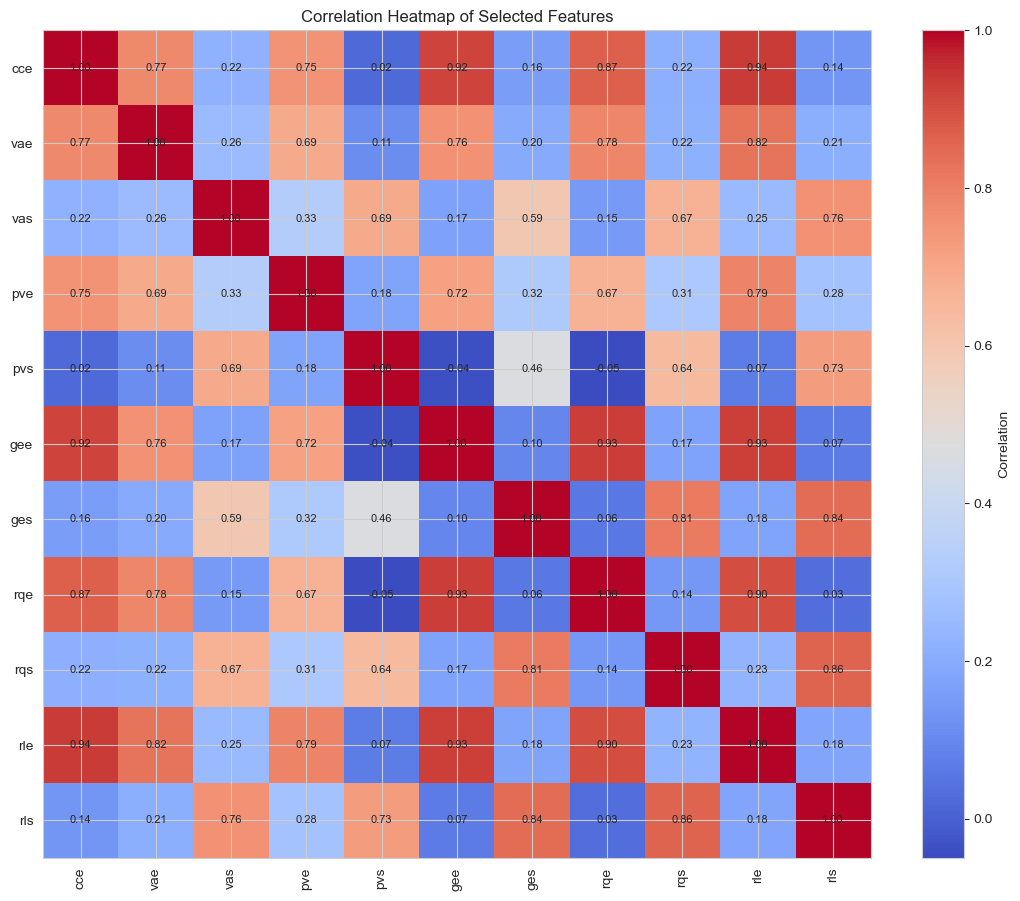

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11,9))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

# Add correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            f"{corr.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Heatmap of Selected Features")

plt.tight_layout()

plt.show()

In [26]:
nan_values = df.isna().sum()
missing_values_table = pd.DataFrame({
    "Missing Values": nan_values,
    "Ratio Missing Values (%)": (nan_values / len(df)) * 100
})
missing_values_table = (
    missing_values_table
    .sort_values(by="Ratio Missing Values (%)", ascending=False)
    .round({"Ratio Missing Values (%)": 2})
    .reset_index()
    .rename(columns={"index": "Column Name"})
)
missing_values_table

,Column Name,Missing Values,Ratio Missing Values (%)
0,gel,243,4.94
1,ges,243,4.94
2,gen,243,4.94
3,ger,243,4.94
4,geu,243,4.94
5,gee,243,4.94
6,rqu,241,4.90
7,rqr,241,4.90
8,rqn,241,4.90
9,rqs,241,4.90


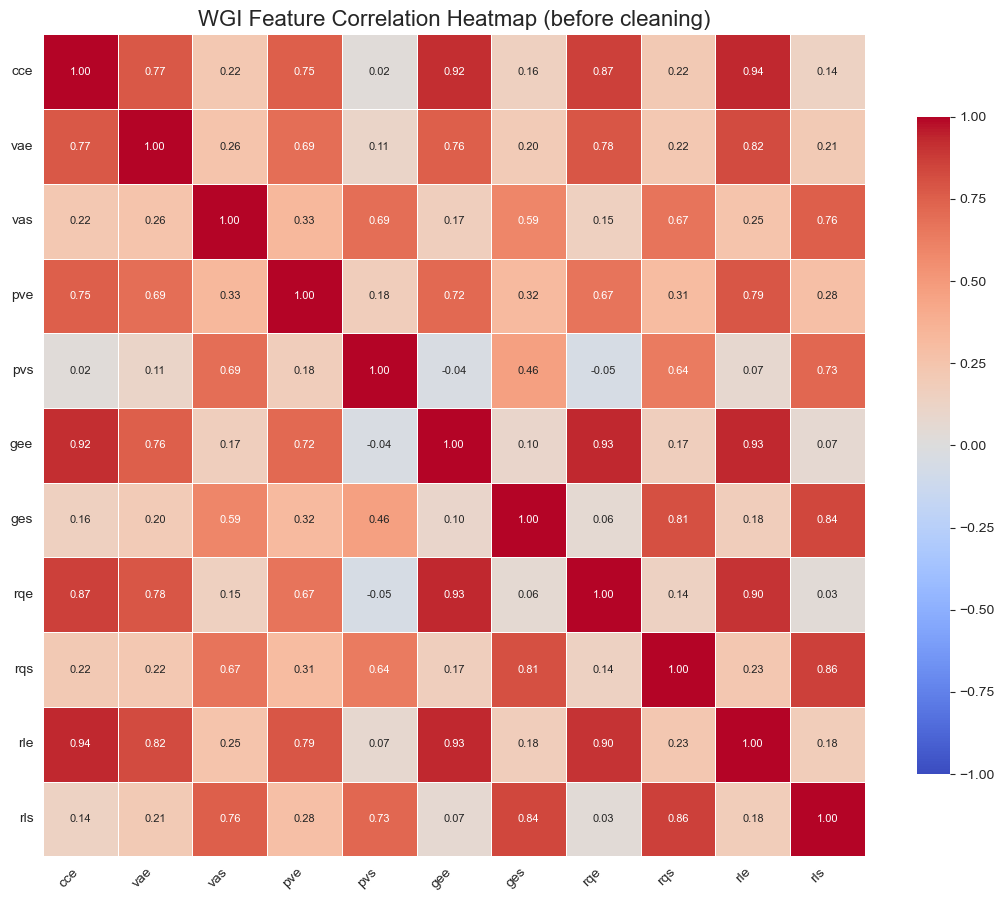

In [32]:
features = [
    "cce",
    "vae", "vas",
    "pve", "pvs",
    "gee", "ges",
    "rqe", "rqs",
    "rle", "rls",
]

corr = df[features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8},
)
plt.title("WGI Feature Correlation Heatmap (before cleaning)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
clean_data = df.copy()

numeric_cols = [c for c in features if c != "cce"] + ["cce"]

clean_data[numeric_cols] = clean_data[numeric_cols].fillna(
    clean_data[numeric_cols].mean()
)
clean_data[numeric_cols].isna().sum()

vae    0
vas    0
pve    0
pvs    0
gee    0
ges    0
rqe    0
rqs    0
rle    0
rls    0
cce    0
dtype: int64

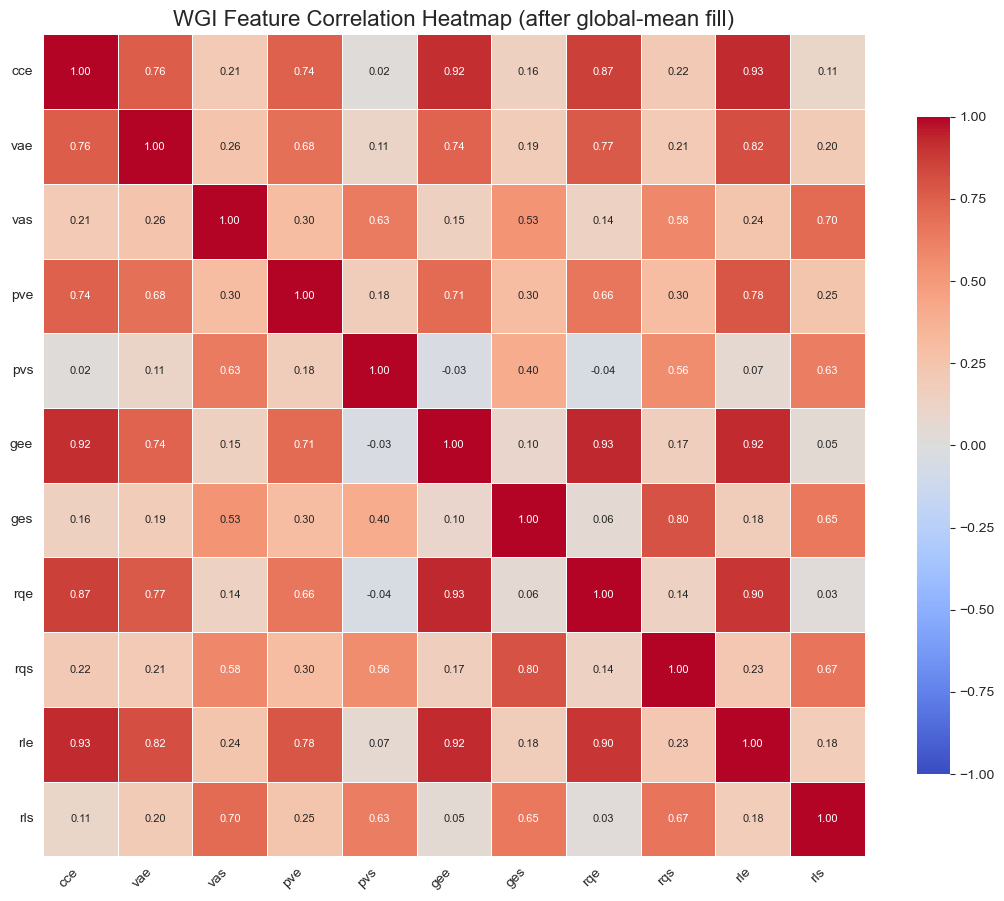

In [34]:
corr = clean_data[features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8},
)
plt.title("WGI Feature Correlation Heatmap (after global-mean fill)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [35]:
col = "rls"  # Rule of Law standard error -- has a representative ~2.6% missing rate
data_sorted = df.sort_values(["countryname", "year"])

# Approach A: global mean
global_mean_fill = data_sorted[col].fillna(data_sorted[col].mean())

# Approach B: within-country linear interpolation
interpolated_fill = (
    data_sorted.groupby("countryname")[col]
    .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
)
interpolated_fill.index = data_sorted.index

print("Missing before:", data_sorted[col].isna().sum())
print("Missing after interpolation:", interpolated_fill.isna().sum())

Missing before: 129
Missing after interpolation: 0


In [36]:
print("Standard deviation, original data only:            ", round(data_sorted[col].std(), 4))
print("Standard deviation, after filling with global mean:  ", round(global_mean_fill.std(), 4))
print("Standard deviation, after interpolating:              ", round(interpolated_fill.std(), 4))

Standard deviation, original data only:             0.1127
Standard deviation, after filling with global mean:   0.1112
Standard deviation, after interpolating:               0.1235


In [37]:
target = "cce"

df_mean = data_sorted.copy()
df_mean[col] = global_mean_fill

df_interp = data_sorted.copy()
df_interp[col] = interpolated_fill

print("Real data only:     ", round(data_sorted[[target, col]].corr().iloc[0, 1], 3))
print("Global mean fill:   ", round(df_mean[[target, col]].corr().iloc[0, 1], 3))
print("Interpolated fill:  ", round(df_interp[[target, col]].corr().iloc[0, 1], 3))

Real data only:      0.136
Global mean fill:    0.136
Interpolated fill:   0.136


In [39]:
missing_by_country = df.groupby("countryname").apply(
    lambda df: df[features].isna().mean() * 100
)
fully_missing = missing_by_country[(missing_by_country == 100).any(axis=1)]
fully_missing

C:\Users\mauri\AppData\Local\Temp\ipykernel_18660\2169194667.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_country = df.groupby("countryname").apply(


,cce,vae,vas,pve,pvs,gee,ges,rqe,rqs,rle,rls
countryname,,,,,,,,,,,
Monaco,100.0,0.0,0.0,17.391304,17.391304,100.0,100.0,100.0,100.0,34.782609,34.782609
San Marino,100.0,0.0,0.0,17.391304,17.391304,100.0,100.0,100.0,100.0,34.782609,34.782609


In [40]:
clean_data_interp = data_sorted.copy()

for column in features:
    clean_data_interp[column] = (
        data_sorted.groupby("countryname")[column]
        .apply(lambda s: s.interpolate(method="linear", limit_direction="both"))
        .values
    )

# drop Monaco and San Marino for the reason given above
clean_data_interp = clean_data_interp[
    ~clean_data_interp["countryname"].isin(["Monaco", "San Marino"])
]

clean_data_interp[features].isna().sum()

cce    0
vae    0
vas    0
pve    0
pvs    0
gee    0
ges    0
rqe    0
rqs    0
rle    0
rls    0
dtype: int64

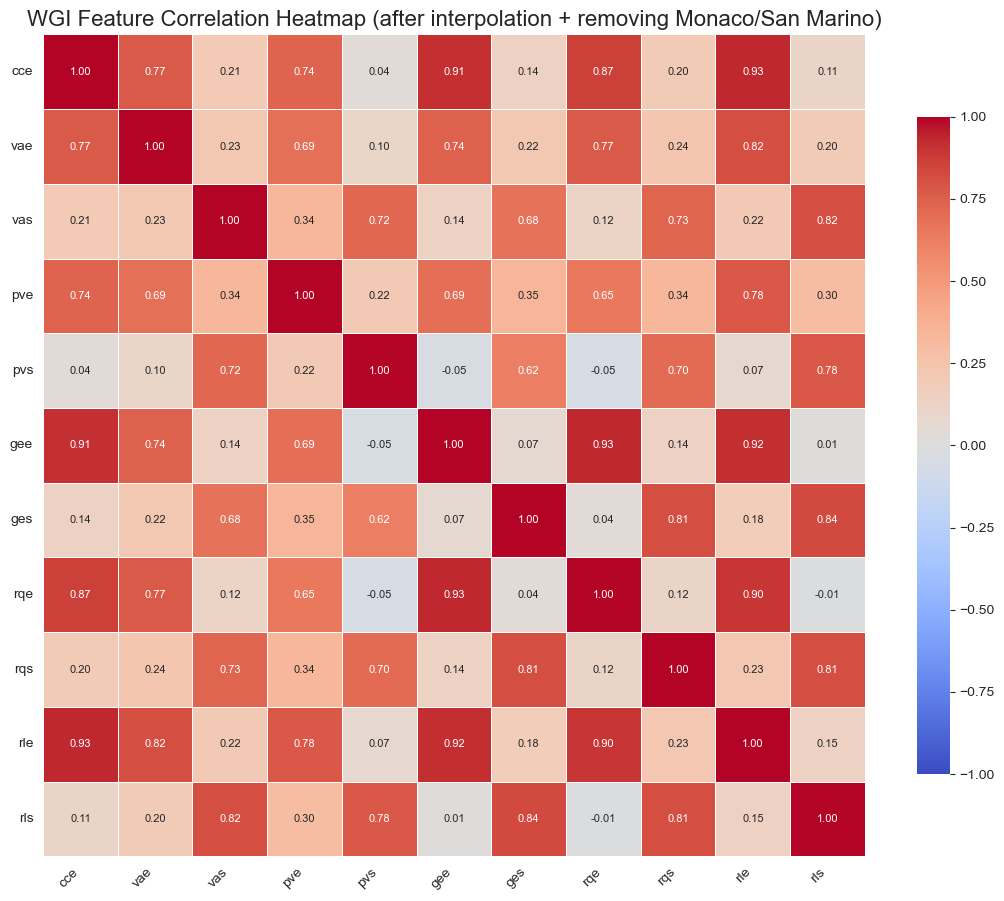

In [41]:
corr = clean_data_interp[features].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={"size": 8},
    cbar_kws={"shrink": 0.8},
)
plt.title("WGI Feature Correlation Heatmap (after interpolation + removing Monaco/San Marino)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_feature_cols = ["vae", "vas", "pve", "pvs", "gee", "ges", "rqe", "rqs", "rle", "rls"]

X_vif = add_constant(clean_data_interp[vif_feature_cols])

vif = pd.DataFrame()
vif["feature"] = X_vif.columns
vif["Variance Inflation Factor"] = [
    variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])
]
vif = vif[vif["feature"] != "const"].sort_values("Variance Inflation Factor", ascending=False)
vif

,feature,Variance Inflation Factor
5,gee,11.477981
9,rle,11.207655
7,rqe,9.400954
10,rls,7.068317
6,ges,4.326720
8,rqs,4.121022
2,vas,3.552978
1,vae,3.394891
3,pve,2.970011
4,pvs,2.929131


In [43]:
columns_to_drop = ["Unnamed: 0", "code", "countryname"]
model_data = clean_data_interp.drop(columns=columns_to_drop)
model_data.shape

(4876, 37)

In [44]:
model_data.columns

Index(['year', 'vae', 'vas', 'van', 'var', 'val', 'vau', 'pve', 'pvs', 'pvn',
       'pvr', 'pvl', 'pvu', 'gee', 'ges', 'gen', 'ger', 'gel', 'geu', 'rqe',
       'rqs', 'rqn', 'rqr', 'rql', 'rqu', 'rle', 'rls', 'rln', 'rlr', 'rll',
       'rlu', 'cce', 'ccs', 'ccn', 'ccr', 'ccl', 'ccu'],
      dtype='object')